# Inpainting with GPR-LIM

June, 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

import gprlim
from pyuvdata import UVData

import gp_utils

In [2]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

# load the meta-data

The data is of shape (Nbaseline, Ntimes, Nfrequencies, Npolarizations) -> (Nbls, Ntimes, Nfreq, Npol).

The data is complex.

Each "baseline" is formed between two antennas, so a baseline index is often denoted as (ant1, ant2).

Frequencies are in Hz, times are in Julian Date (which is just in days). LST is local sidereal time in radians. Polarization is the polarization state of the electric field, which comes in dual linear polarization state (XX, YY, XY, YX). We also call this (EE, NN, EN, NE) for east and north.

The simulation contains two things:
1. a simulation of the "foregrounds" including the synchrotron emission from the Milky Way galactic disk, and the radio galaxy point source background.

2. a simulation of a mock EoR 21cm field. 

so y = fg + eor for "sum".

The "sum.uvh5" has the two summed together. The "eor.uvh5" has just the EoR simulation. We will generate the noise ourselves in the notebook (using this formalism `hera_cal.noise.predict_noise_variance_from_autos`). 


The simulation has 1600 time integrations and 600 frequency bins, and 243 unique baseline vectors.

We call the data the "visibility" which we also sometimes call the "cross-correlatoin visibility" i.e. the cross-correlation between two antennas. The visibility of an antenna with itself (e.g. 0, 0) we call the "auto-correlation" visibility.

We observe at MHz frequencies (120 - 190 MHz).

The data are in units of Jansky (Jy).

In [24]:
# specify frequency channels
freq_chans = range(0, 600)
time_ints = range(0, 1600)

In [4]:
# load metadata only
uvd = UVData()
uvd.read('zen.h6c_idr2_validation.sum.uvh5', read_data=False)

# get antenna information
antpos, ants = uvd.telescope.get_enu_antpos(), uvd.telescope.antenna_numbers
antp = dict(zip(ants.tolist(), antpos))

# get baseline information
all_bls = uvd.get_antpairs()
all_pols = uvd.get_pols()

# get autocorrelation visibility
autocorr, _ = gp_utils.load_uvdata('zen.h6c_idr2_validation.sum.uvh5',
                               bls=[(0, 0)], freq_chans=freq_chans, time_ints=time_ints, device=device)

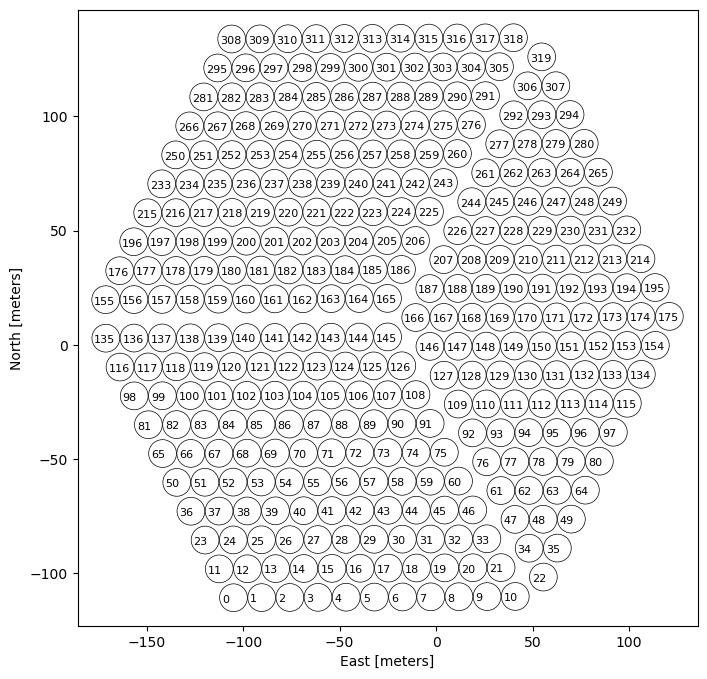

In [5]:
plt.figure(figsize=(8,8))
plt.scatter(*antpos[:, :2].T, fc='none', ec='k', s=400, lw=.5)
for i, a in enumerate(ants):
    plt.text(antpos[i,0]-6, antpos[i,1]-2, a, fontsize=8)
plt.xlabel('East [meters]'); plt.ylabel('North [meters]');

# load the data

In [27]:
# load single baseline data
data, meta = gp_utils.load_uvdata(
    'zen.h6c_idr2_validation.eor.uvh5',
    bls=[(0, 1)],
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = meta['times']
Ntimes = len(times)
reds = meta['reds']

In [30]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(data.nbytes/1e6))

size of data in MB: 15.4


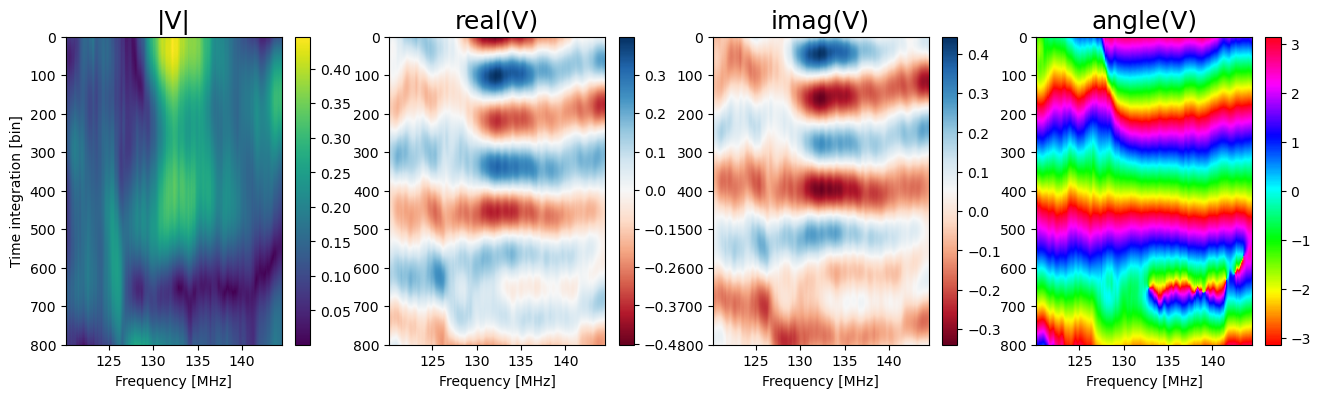

In [9]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# visibility amplitude (abs)
cax = axes[0].imshow(data[0,:,:,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], interpolation='none')
axes[0].set_title("|V|", fontsize=18); cbar = plt.colorbar(cax, ax=axes[0]);
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(data[0,:,:,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='RdBu')
axes[1].set_title("real(V)", fontsize=18); cbar = plt.colorbar(cax, ax=axes[1]);
axes[1].set_xlabel('Frequency [MHz]');

# visibility imag
cax = axes[2].imshow(data[0,:,:,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='RdBu')
axes[2].set_title("imag(V)", fontsize=18); cbar = plt.colorbar(cax, ax=axes[2]);
axes[2].set_xlabel('Frequency [MHz]');

# visibility phase
cax = axes[3].imshow(data[0,:,:,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18); cbar = plt.colorbar(cax, ax=axes[3]);
axes[3].set_xlabel('Frequency [MHz]');

In [11]:
# load flags
flags = np.load('zen.h6c.idr2.2459878.gains.npz')['flags'][3, freq_chans][:, time_ints, 0]
flags = torch.as_tensor(flags.T[None, :, :, None], device=device)

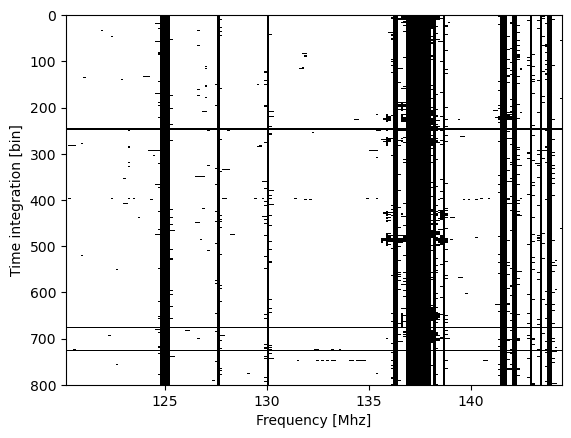

In [15]:
plt.imshow(flags[0, :, :, 0],
           cmap='Greys', aspect='auto', interpolation='none', extent=[freqs[0], freqs[-1], Ntimes, 0]
)
plt.xlabel('Frequency [Mhz]'); plt.ylabel('Time integration [bin]');

# now do 1D GPR